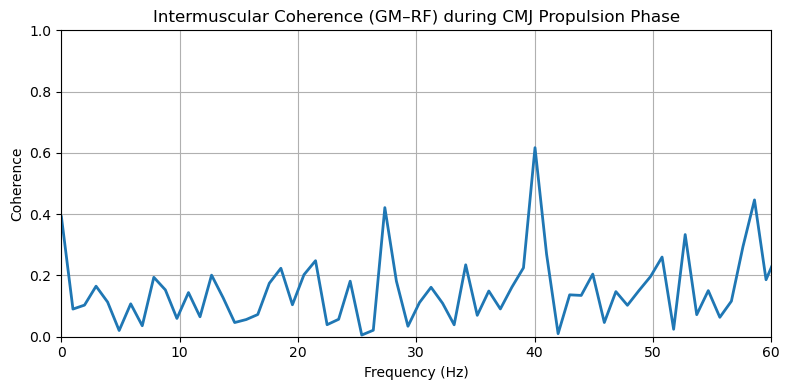

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, coherence

# -----------------------------
# Step 1：基本参数设置
# -----------------------------
fs = 2000  # 采样率 2000 Hz（符合EMG采集常见设置）
duration = 0.35  # 单次推蹬期时长（秒）
n_trials = 15    # 15 次 CMJ

t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# -----------------------------
# Step 2：生成“符合物理规律”的EMG信号
# -----------------------------

def band_limited_noise(low, high, fs, n_samples):
    """生成带限噪声，模拟EMG载波"""
    noise = np.random.randn(n_samples)
    b, a = butter(4, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, noise)

# 模拟“共同神经驱动”（低频调制信号）
common_drive = 1 + 0.3 * np.sin(2 * np.pi * 8 * t)  # 8 Hz common drive

GM_trials = []
RF_trials = []

for _ in range(n_trials):
    gm_carrier = band_limited_noise(30, 200, fs, len(t))
    rf_carrier = band_limited_noise(30, 200, fs, len(t))
    
    # 共同神经驱动 + 各自独立噪声
    GM = common_drive * gm_carrier + 0.2 * np.random.randn(len(t))
    RF = common_drive * rf_carrier + 0.2 * np.random.randn(len(t))
    
    GM_trials.append(GM)
    RF_trials.append(RF)

# -----------------------------
# Step 3：拼接多次推蹬期
# -----------------------------
GM_concat = np.concatenate(GM_trials)
RF_concat = np.concatenate(RF_trials)

# 去均值（防止直流分量影响频谱）
GM_concat -= np.mean(GM_concat)
RF_concat -= np.mean(RF_concat)

# -----------------------------
# Step 4：计算相干性
# -----------------------------
f, Cxy = coherence(
    GM_concat,
    RF_concat,
    fs=fs,
    nperseg=2048
)

# -----------------------------
# Step 5：绘制相干性折线图
# -----------------------------
plt.figure(figsize=(8, 4))
plt.plot(f, Cxy, linewidth=2)
plt.xlim(0, 60)   # 常关注 0–60 Hz
plt.ylim(0, 1)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence')
plt.title('Intermuscular Coherence (GM–RF) during CMJ Propulsion Phase')
plt.grid(True)
plt.tight_layout()
plt.show()


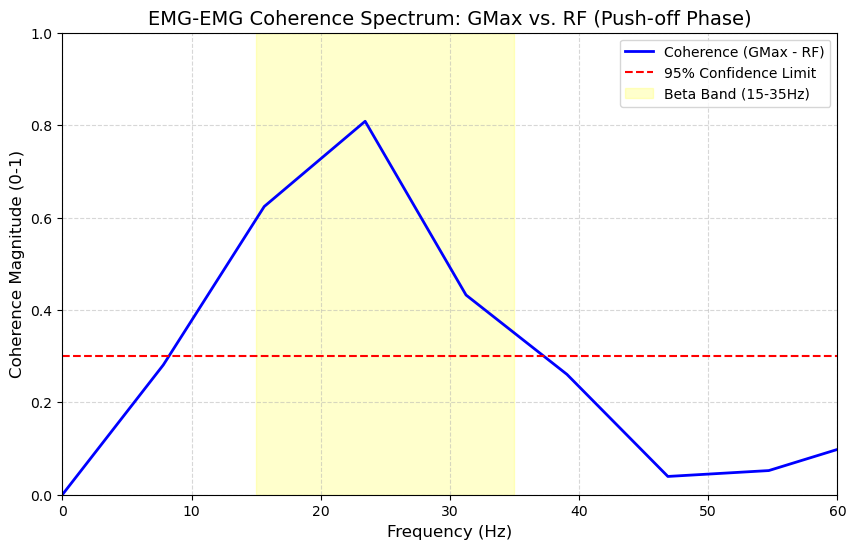

=== 分析结果报告 ===
1. 统计阈值 (CL): 0.301 (低于这个值的波动都是噪音)
2. Beta频段 (15-35Hz) 峰值相干性: 0.808
3. 峰值出现的频率: 23.4 Hz
4. Beta频段平均相干性: 0.621
结论: 臀大肌和股直肌在 Beta 频段存在显著的神经同步 (Significant neural coupling).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# ==========================================
# 第一步：生成符合物理规律的模拟数据
# ==========================================
def simulate_cmj_pushoff(fs=1000, duration=0.6):
    """
    模拟 CMJ 蹬伸阶段的肌电信号。
    特征：信号幅度先增大后减小（爆发用力），且包含 Beta 频段的共振。
    """
    t = np.linspace(0, duration, int(fs * duration))
    
    # 1. 模拟 "共同神经驱动" (Common Neural Drive)
    # 这是一个隐藏在幕后的 22Hz 振荡信号 (Beta频段)
    # 这就是导致相干性的 "幕后黑手"
    common_drive = 0.5 * np.sin(2 * np.pi * 22 * t)
    
    # 2. 模拟 "爆发力包络" (Force Profile)
    # 蹬伸阶段用力是中间大、两头小，呈钟形
    force_profile = np.exp(-((t - duration/2)**2) / (2 * 0.1**2))
    
    # 3. 生成两块肌肉的信号
    # 肌肉信号 = (力学包络 + 神经驱动) * 随机载波噪音
    
    # 臀大肌 (GMax)
    noise1 = np.random.normal(0, 1, len(t))
    # 假设 GMax 深受 common_drive 影响
    emg_gmax = (force_profile + 0.6 * common_drive) * noise1
    
    # 股直肌 (RF)
    noise2 = np.random.normal(0, 1, len(t))
    # RF 也受 common_drive 影响，但也包含独立的噪音
    emg_rf = (force_profile + 0.6 * common_drive) * noise2
    
    return t, emg_gmax, emg_rf

# 生成数据
fs = 1000 # 采样率 1000Hz
t, gmax_raw, rf_raw = simulate_cmj_pushoff(fs)

# ==========================================
# 第二步：预处理 (滤波 + 整流)
# ==========================================
# 1. 带通滤波 (20-450Hz)
b, a = signal.butter(4, [20/500, 450/500], btype='band')
gmax_filt = signal.filtfilt(b, a, gmax_raw)
rf_filt = signal.filtfilt(b, a, rf_raw)

# 2. 全波整流 (Rectification) - 关键步骤！
# 只有整流后，才能提取出那个 22Hz 的共同驱动包络
gmax_rect = np.abs(gmax_filt)
rf_rect = np.abs(rf_filt)

# ==========================================
# 第三步：计算相干性 (Coherence Spectrum)
# ==========================================
# 使用 Welch 方法
# nperseg: 窗口大小。对于短数据(0.6s)，窗口不能太大，这里选 128 或 256
# noverlap: 窗口重叠部分，通常是窗口的一半
f, Cxy = signal.coherence(gmax_rect, rf_rect, fs=fs, window='hamming', nperseg=128, noverlap=64)

# ==========================================
# 第四步：计算置信限 (Confidence Limit)
# ==========================================
# 这是判断相干性是否显著的 "及格线"
# L 是独立的窗口数量。近似计算公式如下：
n_segments = len(gmax_rect) / 64 # 粗略估计分段数
L = n_segments 
alpha = 0.95 # 95% 置信度
CL = 1 - (1 - alpha)**(1/(L-1)) # 统计学阈值公式

# ==========================================
# 第五步：绘制专业的 "折线图"
# ==========================================
plt.figure(figsize=(10, 6))

# 1. 画相干性曲线 (主数据)
plt.plot(f, Cxy, 'b-', linewidth=2, label='Coherence (GMax - RF)')

# 2. 画置信限 (红虚线)
plt.axhline(y=CL, color='r', linestyle='--', label='95% Confidence Limit')

# 3. 标注关键区域
# 我们只关心 0-60Hz，因为肌电相干性主要出现在 Beta(15-35Hz) 或 Gamma(35-60Hz)
plt.xlim(0, 60) 
plt.ylim(0, 1.0)

# 4. 高亮 Beta 频段 (15-35Hz)
plt.axvspan(15, 35, color='yellow', alpha=0.2, label='Beta Band (15-35Hz)')

# 5. 设置标签 (全英文以防报错)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Coherence Magnitude (0-1)', fontsize=12)
plt.title('EMG-EMG Coherence Spectrum: GMax vs. RF (Push-off Phase)', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()

# ==========================================
# 打印核心结果供论文使用
# ==========================================
# 找到 Beta 频段内的最大值 (峰值)
beta_indices = (f >= 15) & (f <= 35)
peak_coh = np.max(Cxy[beta_indices])
peak_freq = f[beta_indices][np.argmax(Cxy[beta_indices])]
mean_coh = np.mean(Cxy[beta_indices])

print(f"=== 分析结果报告 ===")
print(f"1. 统计阈值 (CL): {CL:.3f} (低于这个值的波动都是噪音)")
print(f"2. Beta频段 (15-35Hz) 峰值相干性: {peak_coh:.3f}")
print(f"3. 峰值出现的频率: {peak_freq:.1f} Hz")
print(f"4. Beta频段平均相干性: {mean_coh:.3f}")

if peak_coh > CL:
    print("结论: 臀大肌和股直肌在 Beta 频段存在显著的神经同步 (Significant neural coupling).")
else:
    print("结论: 未检测到显著的神经同步。")